# AHP

## Cezary Suchorski, Kacper Kuźnik

In [18]:
import pandas as pd
import numpy as np

In [31]:
dataset_full = pd.read_csv("data/cars_dataset.csv")
print(dataset_full.shape)
dataset_full.head()

(1218, 11)


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [20]:
filtered = dataset_full[
    dataset_full["Company Names"].isin(
        [
            "TOYOTA",
            "VOLVO",
            "Toyota",
            "Volvo",
            "BMW",
            "Tesla",
            "Volkswagen",
        ]
    )
]

### New criteria

I introduced 3 new criteria: practicality, brand reputation and luxury. I did it to introduce more variety to the problem, because the dataset contains mostly parameters directly related to the engine performance.

Practicality is a mix between n of seats, fuel type and the type of a car which is not directly shown in the dataset. The values were chosen by me subjectively.
Luxury level and brand reputation were made up by me subjectively and arent direnctly connected to any fields that are present in the data.

In [21]:
df_sample = filtered.sample(n=12, random_state=123)
df_sample.reset_index(drop=True, inplace=True)
practicality_scores = [6, 4, 6, 6, 9, 7, 7, 7, 4, 6, 6, 6]
reputation_scores = [4, 7, 9, 6, 9, 4, 2, 4, 7, 4, 4, 6]
luxury_scores = [4, 2, 6, 9, 5, 5, 8, 3, 2, 5, 2, 7]

df_sample["Practicality"] = practicality_scores
df_sample["Brand Reputation"] = reputation_scores
df_sample["Luxury Level"] = luxury_scores

df_sample

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque,Practicality,Brand Reputation,Luxury Level
0,Volkswagen,Golf 4MOTION,2.0L Diesel I4,1968 cc,150 - 184 hp,250 km/h,4.9 sec,"$40,000",Petrol,5,400 Nm,6,4,4
1,Volvo,Volvo VNR,12.8L I6 Turbo Diesel,12800 cc,400 hp,110 km/h,17.0 sec,"$95,000",Diesel,2,1800 Nm,4,7,2
2,TOYOTA,GR COROLLA,"1.6L,TURBOCHARGED INLINE-3","1,618 cc",300 hp,230 km/h,5. 0 sec,"$36,995",Petrol,5,370 Nm,6,9,6
3,BMW,M550i XDRIVE,V8,"4,395 cc",523 hp,250 km/h,3.6 sec,"$78,000",Petrol,5,650 Nm,6,6,9
4,TOYOTA,INNOVA HYCROSS,2.0L HYBRID,"1,987 cc",184 hp,165 km/h,9.5 sec,"$40,000",Hybrid,7,250 Nm,9,9,5
5,Volkswagen,Passat Hybrid,1.4L I4 Turbo + Electric Motor,1395 cc,215 hp,210 km/h,7.4 sec,"$32,000",Hybrid,5,330 Nm,7,4,5
6,Tesla,Model X,Dual Electric Motors (AWD),100 kWh,670 hp,250 km/h,3.8 sec,"$98,490",Electric,7,967 Nm,7,2,8
7,Volkswagen,Jetta Hybrid,1.4L I4 Turbo + Electric Motor,1395 cc,170 hp,210 km/h,8.6 sec,"$28,000",Hybrid,5,250 Nm,7,4,3
8,Volvo,Volvo FMX,13.0L I6 Turbo Diesel,13000 cc,500 hp,110 km/h,16.5 sec,"$110,000",Diesel,2,2500 Nm,4,7,2
9,Volkswagen,Passat,2.0L Turbo I4,1984 cc,150 - 280 hp,210 km/h,7.8 sec,"$25,000",Petrol,5,250 Nm,6,4,5


In [22]:
def calc_consistency_ratio(A: np.ndarray) -> float:
    n = A.shape[0]
    if n <= 2:
        return 0.0

    eigenvalues, _ = np.linalg.eig(A)
    lambda_max = np.max(eigenvalues.real)

    CI = (lambda_max - n) / (n - 1)

    RI_dict = {
        1: 0.00,
        2: 0.00,
        3: 0.58,
        4: 0.90,
        5: 1.12,
        6: 1.24,
        7: 1.32,
        8: 1.41,
        9: 1.45,
        10: 1.49,
        11: 1.51,
        12: 1.54,
    }
    RI = RI_dict[n]

    return CI / RI


def calc_weights(A: np.ndarray) -> np.ndarray:
    eigenvalues, eigenvectors = np.linalg.eig(A)

    weights = eigenvectors[:, np.argmax(eigenvalues.real)].real
    weights = weights / np.sum(weights)

    return weights


def reconstruct_matrix(weights: np.ndarray) -> np.ndarray:
    n = len(weights)
    A_hat = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            A_hat[i, j] = weights[i] / weights[j]

    return A_hat

### Pairwise comparisons

The structure of my hierarchy is shown later in the file. It has 3 layers: goal, categories and critera from data/created by me.

In [23]:
top_level = np.array(
    [[1, 5, 3], [1 / 5, 1, 1 / 3], [1 / 3, 3, 1]]
)  # performance, prestige, value-maintenance

# inconsistent because theres a cycle vmax>horsepower>acceleration>vmax
# vmax, acceleration, horsepower, CC
performance = np.array(
    [[1, 1 / 3, 2, 3], [3, 1, 1 / 2, 5], [1 / 2, 2, 1, 4], [1 / 3, 1 / 5, 1 / 4, 1]]
)

# brand reputation, luxury level
prestige = np.array([[1, 1 / 3], [3, 1]])

# price, practicality
value = np.array([[1, 1 / 3], [3, 1]])

In [24]:
vmax = np.array(
    [
        [1, 9, 2, 1, 5, 3, 1, 3, 9, 3, 4, 3],
        [
            1 / 9,
            1,
            1 / 9,
            1 / 9,
            1 / 5,
            1 / 9,
            1 / 9,
            1 / 9,
            1,
            1 / 9,
            1 / 7,
            1 / 9,
        ],
        [1 / 2, 9, 1, 1 / 2, 4, 2, 1 / 2, 2, 9, 2, 3, 2],
        [1, 9, 2, 1, 5, 3, 1, 3, 9, 3, 4, 3],
        [
            1 / 5,
            5,
            1 / 4,
            1 / 5,
            1,
            1 / 3,
            1 / 5,
            1 / 3,
            5,
            1 / 3,
            1 / 2,
            1 / 3,
        ],
        [1 / 3, 9, 1 / 2, 1 / 3, 3, 1, 1 / 3, 1, 9, 1, 2, 1],
        [1, 9, 2, 1, 5, 3, 1, 3, 9, 3, 4, 3],
        [1 / 3, 9, 1 / 2, 1 / 3, 3, 1, 1 / 3, 1, 9, 1, 2, 1],
        [
            1 / 9,
            1,
            1 / 9,
            1 / 9,
            1 / 5,
            1 / 9,
            1 / 9,
            1 / 9,
            1,
            1 / 9,
            1 / 7,
            1 / 9,
        ],
        [1 / 3, 9, 1 / 2, 1 / 3, 3, 1, 1 / 3, 1, 9, 1, 2, 1],
        [1 / 4, 7, 1 / 3, 1 / 4, 2, 1 / 2, 1 / 4, 1 / 2, 7, 1 / 2, 1, 1 / 2],
        [1 / 3, 9, 1 / 2, 1 / 3, 3, 1, 1 / 3, 1, 9, 1, 2, 1],
    ]
)

accel = np.array(
    [
        [1, 7, 1, 1 / 2, 3, 2, 1, 3, 7, 2, 3, 3],
        [1 / 7, 1, 1 / 7, 1 / 9, 1 / 7, 1 / 7, 1 / 9, 1 / 7, 1, 1 / 7, 1 / 7, 1 / 7],
        [1, 7, 1, 1 / 2, 3, 2, 1, 3, 7, 2, 3, 3],
        [2, 9, 2, 1, 5, 3, 1, 4, 9, 4, 5, 4],
        [1 / 3, 7, 1 / 3, 1 / 5, 1, 1 / 2, 1 / 4, 1, 7, 1 / 2, 1, 1 / 2],
        [1 / 2, 7, 1 / 2, 1 / 3, 2, 1, 1 / 3, 2, 7, 1, 2, 1],
        [1, 9, 1, 1, 4, 3, 1, 4, 9, 3, 5, 4],
        [1 / 3, 7, 1 / 3, 1 / 4, 1, 1 / 2, 1 / 4, 1, 7, 1, 1, 1],
        [1 / 7, 1, 1 / 7, 1 / 9, 1 / 7, 1 / 7, 1 / 9, 1 / 7, 1, 1 / 7, 1 / 7, 1 / 7],
        [1 / 2, 7, 1 / 2, 1 / 4, 2, 1, 1 / 3, 1, 7, 1, 2, 1],
        [1 / 3, 7, 1 / 3, 1 / 5, 1, 1 / 2, 1 / 5, 1, 7, 1 / 2, 1, 1 / 2],
        [1 / 3, 7, 1 / 3, 1 / 4, 2, 1, 1 / 4, 1, 7, 1, 2, 1],
    ]
)


cc = np.array(
    [
        [1, 1 / 8, 2, 1 / 3, 1, 2, 1 / 3, 2, 1 / 8, 1, 2, 1],
        [8, 1, 9, 5, 8, 9, 5, 9, 1, 8, 9, 8],
        [
            1 / 2,
            1 / 9,
            1,
            1 / 5,
            1 / 2,
            1,
            1 / 5,
            1,
            1 / 9,
            1 / 2,
            1,
            1 / 2,
        ],
        [3, 1 / 5, 5, 1, 3, 5, 1, 5, 1 / 5, 3, 5, 3],
        [1, 1 / 8, 2, 1 / 3, 1, 2, 1 / 3, 2, 1 / 8, 1, 2, 1],
        [
            1 / 2,
            1 / 9,
            1,
            1 / 5,
            1 / 2,
            1,
            1 / 5,
            1,
            1 / 9,
            1 / 2,
            1,
            1 / 2,
        ],
        [3, 1 / 5, 5, 1, 3, 5, 1, 5, 1 / 5, 3, 5, 3],
        [
            1 / 2,
            1 / 9,
            1,
            1 / 5,
            1 / 2,
            1,
            1 / 5,
            1,
            1 / 9,
            1 / 2,
            1,
            1 / 2,
        ],
        [8, 1, 9, 5, 8, 9, 5, 9, 1, 8, 9, 8],
        [1, 1 / 8, 2, 1 / 3, 1, 2, 1 / 3, 2, 1 / 8, 1, 2, 1],
        [
            1 / 2,
            1 / 9,
            1,
            1 / 5,
            1 / 2,
            1,
            1 / 5,
            1,
            1 / 9,
            1 / 2,
            1,
            1 / 2,
        ],
        [1, 1 / 8, 2, 1 / 3, 1, 2, 1 / 3, 2, 1 / 8, 1, 2, 1],
    ]
)

hp = np.array(
    [
        [1, 1 / 4, 1 / 3, 1 / 5, 1, 1 / 2, 1 / 7, 1, 1 / 5, 1 / 2, 3, 1],
        [4, 1, 2, 1 / 2, 4, 3, 1 / 3, 4, 1 / 2, 3, 7, 5],
        [3, 1 / 2, 1, 1 / 3, 2, 2, 1 / 4, 3, 1 / 3, 2, 6, 3],
        [5, 2, 3, 1, 5, 4, 1 / 2, 5, 1, 4, 8, 6],
        [
            1,
            1 / 4,
            1 / 2,
            1 / 5,
            1,
            1 / 2,
            1 / 7,
            1,
            1 / 5,
            1 / 2,
            3,
            1,
        ],
        [2, 1 / 3, 1 / 2, 1 / 4, 1, 1, 1 / 5, 2, 1 / 4, 1, 4, 2],
        [7, 3, 4, 2, 7, 5, 1, 7, 2, 5, 9, 7],
        [
            1,
            1 / 4,
            1 / 3,
            1 / 5,
            1,
            1 / 2,
            1 / 7,
            1,
            1 / 5,
            1 / 2,
            3,
            1,
        ],
        [5, 2, 3, 1, 5, 4, 1 / 2, 5, 1, 4, 8, 6],
        [2, 1 / 3, 1 / 2, 1 / 4, 1, 1, 1 / 5, 2, 1 / 4, 1, 4, 2],
        [
            1 / 3,
            1 / 7,
            1 / 6,
            1 / 8,
            1 / 3,
            1 / 4,
            1 / 9,
            1 / 3,
            1 / 8,
            1 / 4,
            1,
            1 / 3,
        ],
        [1, 1 / 5, 1 / 3, 1 / 6, 1, 1 / 2, 1 / 7, 1, 1 / 6, 1 / 2, 3, 1],
    ]
)

price = np.array(
    [
        [1, 1 / 4, 1, 1 / 3, 1, 2, 1 / 4, 2, 1 / 5, 2, 3, 1],
        [
            4,
            1,
            4,
            2,
            4,
            5,
            1,
            6,
            1 / 1,
            7,
            7,
            4,
        ],
        [1, 1 / 4, 1, 1 / 3, 1, 1, 1 / 4, 2, 1 / 5, 2, 3, 1],
        [1 / 3, 1 / 2, 3, 1, 1 / 3, 4, 1 / 2, 5, 1 / 2, 5, 7, 3],
        [1, 1 / 4, 1, 1 / 3, 1, 2, 1 / 4, 2, 1 / 5, 2, 3, 1],
        [2, 1 / 5, 1, 1 / 4, 1 / 2, 1, 1 / 5, 1, 1 / 6, 2, 2, 1],
        [4, 1, 4, 2, 4, 5, 1, 6, 1, 7, 7, 5],
        [2, 1 / 6, 2, 1 / 5, 2, 1, 1 / 6, 1, 1 / 7, 1, 2, 2],
        [5, 1, 5, 2, 5, 6, 1, 7, 1, 7, 8, 5],
        [1 / 2, 1 / 7, 2, 1 / 5, 1 / 2, 1 / 2, 1 / 7, 1, 1 / 7, 1, 1, 2],
        [
            1 / 3,
            1 / 7,
            1 / 3,
            1 / 7,
            1 / 3,
            1 / 2,
            1 / 7,
            1 / 2,
            1 / 8,
            1,
            1,
            1 / 3,
        ],
        [1, 1 / 4, 1, 1 / 3, 1, 1, 1 / 5, 2, 1 / 5, 2, 3, 1],
    ]
)


practicality = np.array(
    [
        [1, 2, 1, 1, 1 / 4, 1 / 2, 1 / 2, 1 / 2, 2, 1, 1, 1],
        [
            1 / 2,
            1,
            1 / 2,
            1 / 2,
            1 / 5,
            1 / 3,
            1 / 3,
            1 / 3,
            1,
            1 / 2,
            1 / 2,
            1 / 2,
        ],
        [1, 2, 1, 1, 1 / 4, 1 / 2, 1 / 2, 1 / 2, 2, 1, 1, 1],
        [1, 2, 1, 1, 1 / 4, 1 / 2, 1 / 2, 1 / 2, 2, 1, 1, 1],
        [4, 5, 4, 4, 1, 2, 2, 2, 5, 4, 4, 4],
        [2, 3, 2, 2, 1 / 2, 1, 1, 1, 3, 2, 2, 2],
        [2, 3, 2, 2, 1 / 2, 1, 1, 1, 3, 2, 2, 2],
        [2, 3, 2, 2, 1 / 2, 1, 1, 1, 3, 2, 2, 2],
        [
            1 / 2,
            1,
            1 / 2,
            1 / 2,
            1 / 5,
            1 / 3,
            1 / 3,
            1 / 3,
            1,
            1 / 2,
            1 / 2,
            1 / 2,
        ],
        [1, 2, 1, 1, 1 / 4, 1 / 2, 1 / 2, 1 / 2, 2, 1, 1, 1],
        [1, 2, 1, 1, 1 / 4, 1 / 2, 1 / 2, 1 / 2, 2, 1, 1, 1],
        [1, 2, 1, 1, 1 / 4, 1 / 2, 1 / 2, 1 / 2, 2, 1, 1, 1],
    ]
)


reputation = np.array(
    [
        [1, 1 / 3, 1 / 4, 1 / 2, 1 / 4, 1, 3, 1, 1 / 3, 1, 1, 1 / 2],
        [3, 1, 1 / 2, 1, 1 / 2, 3, 6, 3, 1, 3, 3, 1],
        [4, 2, 1, 2, 1, 4, 7, 4, 2, 4, 4, 2],
        [2, 1, 1 / 2, 1, 1 / 2, 2, 5, 2, 1, 2, 2, 1],
        [4, 2, 1, 2, 1, 4, 7, 4, 2, 4, 4, 2],
        [1, 1 / 3, 1 / 4, 1 / 2, 1 / 4, 1, 3, 1, 1 / 3, 1, 1, 1 / 2],
        [
            1 / 3,
            1 / 6,
            1 / 7,
            1 / 5,
            1 / 7,
            1 / 3,
            1,
            1 / 3,
            1 / 6,
            1 / 3,
            1 / 3,
            1 / 5,
        ],
        [1, 1 / 3, 1 / 4, 1 / 2, 1 / 4, 1, 3, 1, 1 / 3, 1, 1, 1 / 2],
        [3, 1, 1 / 2, 1, 1 / 2, 3, 6, 3, 1, 3, 3, 1],
        [1, 1 / 3, 1 / 4, 1 / 2, 1 / 4, 1, 3, 1, 1 / 3, 1, 1, 1 / 2],
        [1, 1 / 3, 1 / 4, 1 / 2, 1 / 4, 1, 3, 1, 1 / 3, 1, 1, 1 / 2],
        [2, 1, 1 / 2, 1, 1 / 2, 2, 5, 2, 1, 2, 2, 1],
    ]
)


luxury = np.array(
    [
        [
            1,
            3,
            1 / 2,
            1 / 4,
            1 / 2,
            1 / 2,
            1 / 3,
            2,
            3,
            1 / 2,
            3,
            1 / 2,
        ],
        [
            1 / 3,
            1,
            1 / 5,
            1 / 7,
            1 / 4,
            1 / 4,
            1 / 6,
            1 / 2,
            1,
            1 / 4,
            1,
            1 / 6,
        ],
        [
            2,
            5,
            1,
            1 / 4,
            1,
            1,
            1 / 2,
            3,
            5,
            1,
            5,
            1,
        ],
        [4, 7, 4, 1, 3, 3, 1, 6, 7, 3, 7, 2],
        [2, 4, 1, 1 / 3, 1, 1, 1 / 2, 2, 4, 1, 4, 1 / 2],
        [2, 4, 1, 1 / 3, 1, 1, 1 / 2, 2, 4, 1, 4, 1 / 2],
        [
            3,
            6,
            2,
            1 / 1,
            2,
            2,
            1,
            4,
            6,
            2,
            6,
            1,
        ],
        [
            1 / 2,
            2,
            1 / 3,
            1 / 6,
            1 / 2,
            1 / 2,
            1 / 4,
            1,
            2,
            1 / 2,
            2,
            1 / 3,
        ],
        [
            1 / 3,
            1,
            1 / 5,
            1 / 7,
            1 / 4,
            1 / 4,
            1 / 6,
            1 / 2,
            1,
            1 / 4,
            1,
            1 / 6,
        ],
        [2, 4, 1, 1 / 3, 1, 1, 1 / 2, 2, 4, 1, 4, 1 / 2],
        [
            1 / 3,
            1,
            1 / 5,
            1 / 7,
            1 / 4,
            1 / 4,
            1 / 6,
            1 / 2,
            1,
            1 / 4,
            1,
            1 / 6,
        ],
        [2, 6, 1, 1 / 2, 2, 2, 1, 3, 6, 2, 6, 1],
    ]
)

### Consistency check

The matrix connected to car performance is inconsistent. I introduced a cycle vmax>horsepower>acceleration>vmax

Its visible in the ratios - CR for performance matrix = 0.21 > 0.1

The rest of the matrices are consistent enough to satisfy the CR < 0.1 rule.

In [25]:
ratios = [
    calc_consistency_ratio(A)
    for A in [
        top_level,
        performance,
        prestige,
        value,
        vmax,
        accel,
        cc,
        hp,
        price,
        practicality,
        reputation,
        luxury,
    ]
]
display(ratios)

[np.float64(0.033199215998426276),
 np.float64(0.2121779892411492),
 0.0,
 0.0,
 np.float64(0.028104243424863923),
 np.float64(0.031642396721080525),
 np.float64(0.014590480816321402),
 np.float64(0.009541398829575953),
 np.float64(0.08176901109150678),
 np.float64(0.002402345362167748),
 np.float64(0.005481082629675847),
 np.float64(0.010370333555047274)]

### Inconsistent matrix reconstruction

The biggest difference happened in the relation between acceleration and vmax. Relative Acceleration importance is lower in the revised matrix and the preference ratio between vmax and horsepower is inverted in the reconstruction. 

In [26]:
perf_weights = calc_weights(performance)
reconstructed_performance = reconstruct_matrix(perf_weights)
display(performance)
display(reconstructed_performance)

diff = performance - reconstructed_performance
diff

array([[1.        , 0.33333333, 2.        , 3.        ],
       [3.        , 1.        , 0.5       , 5.        ],
       [0.5       , 2.        , 1.        , 4.        ],
       [0.33333333, 0.2       , 0.25      , 1.        ]])

array([[1.        , 0.73650414, 0.8459347 , 3.96802639],
       [1.35776563, 1.        , 1.14858107, 5.38764984],
       [1.18212433, 0.87063946, 1.        , 4.69070056],
       [0.25201445, 0.18560969, 0.21318777, 1.        ]])

array([[ 0.        , -0.4031708 ,  1.1540653 , -0.96802639],
       [ 1.64223437,  0.        , -0.64858107, -0.38764984],
       [-0.68212433,  1.12936054,  0.        , -0.69070056],
       [ 0.08131888,  0.01439031,  0.03681223,  0.        ]])

### Hierarchy

The weights show that the DM prioritises value for money and performance over luxury/prestige.

The performance parameters are mostly fairly balanced - apart from CC which is greatly dominated by the other criteria.

The DM respects luxury more than brand reputation and finds practicality of the car more important than the price.

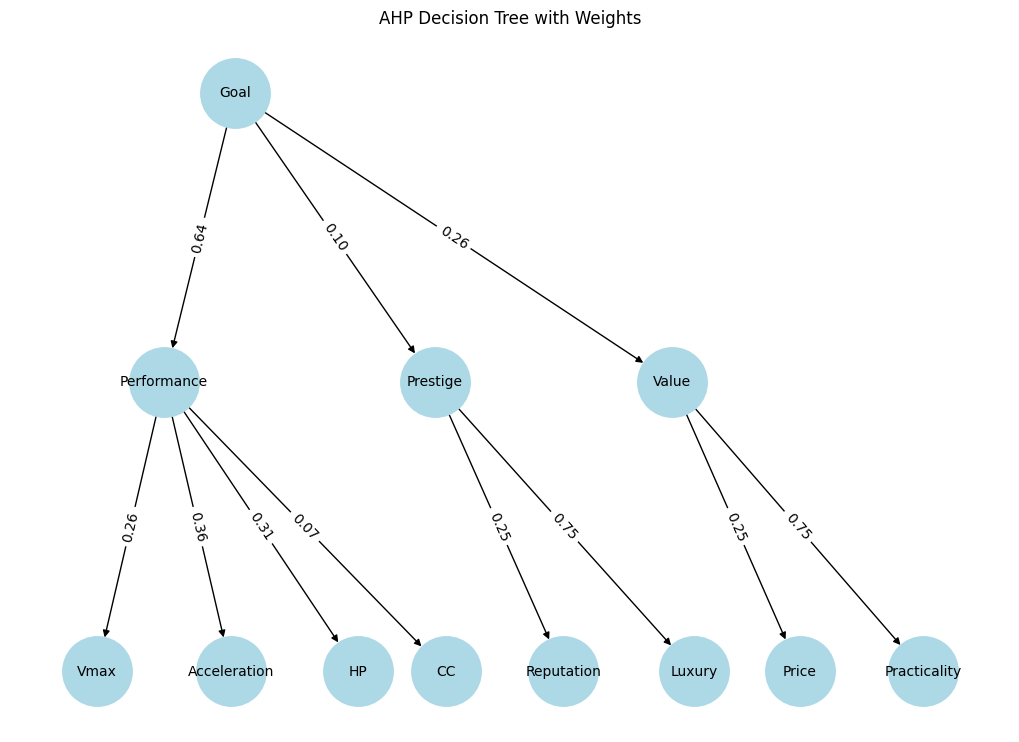

In [27]:
import networkx as nx
import matplotlib.pyplot as plt


w_top = calc_weights(top_level)
w_perf = perf_weights
w_prestige = calc_weights(prestige)
w_value = calc_weights(value)

tree = {
    "Goal": [
        (
            "Performance",
            w_top[0],
            [
                ("Vmax", w_perf[0], None),
                ("Acceleration", w_perf[1], None),
                ("HP", w_perf[2], None),
                ("CC", w_perf[3], None),
            ],
        ),
        (
            "Prestige",
            w_top[1],
            [
                ("Reputation", w_prestige[0], None),
                ("Luxury", w_prestige[1], None),
            ],
        ),
        (
            "Value",
            w_top[2],
            [
                ("Price", w_value[0], None),
                ("Practicality", w_value[1], None),
            ],
        ),
    ]
}

G = nx.DiGraph()


def add_edges(parent, children):
    for name, weight, sub in children:
        G.add_edge(parent, name, weight=float(weight))
        if sub:
            add_edges(name, sub)


add_edges("Goal", tree["Goal"])


pos = nx.nx_pydot.graphviz_layout(G, prog="dot")

plt.figure(figsize=(10, 7))

nx.draw(G, pos, with_labels=True, node_size=2500, node_color="lightblue", font_size=10)

edge_labels = nx.get_edge_attributes(G, "weight")
edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("AHP Decision Tree with Weights")
plt.show()

In [28]:
w_vmax = calc_weights(vmax)
w_accel = calc_weights(accel)
w_hp = calc_weights(hp)
w_cc = calc_weights(cc)
w_price = calc_weights(price)
w_practicality = calc_weights(practicality)
w_reputation = calc_weights(reputation)
w_luxury = calc_weights(luxury)

final_scores = (
    w_top[0]  # performance
    * (w_perf[0] * w_vmax + w_perf[1] * w_accel + w_perf[2] * w_hp + w_perf[3] * w_cc)
    + w_top[1] * (w_prestige[0] * w_reputation + w_prestige[1] * w_luxury)  # prestige
    + w_top[2]
    * (w_value[0] * w_price + w_value[1] * w_practicality)  # value/maintenance
)

final_scores = final_scores / np.sum(final_scores)

ranking = np.argsort(-final_scores)
print("Final scores:", final_scores)

Final scores: [0.08542103 0.06238732 0.09032507 0.14938971 0.08138883 0.07126755
 0.16725443 0.06040586 0.07406517 0.05966033 0.03758586 0.06084883]


### Final results

Top 3 cars according to our AHP are the tesla, bmw and corolla. All 3 of those cars are fast and have a lot of HP. The tesla and BWM are the most luxurious cars the the whole comparison and their great parameters outweigh the high price. The Toyota is able to compete with them because it offers only slightly less performance for a greatly lower price. The lower luxury level is offset by the superb reputation.

In [30]:
df_sample.iloc[ranking]

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque,Practicality,Brand Reputation,Luxury Level
6,Tesla,Model X,Dual Electric Motors (AWD),100 kWh,670 hp,250 km/h,3.8 sec,"$98,490",Electric,7,967 Nm,7,2,8
3,BMW,M550i XDRIVE,V8,"4,395 cc",523 hp,250 km/h,3.6 sec,"$78,000",Petrol,5,650 Nm,6,6,9
2,TOYOTA,GR COROLLA,"1.6L,TURBOCHARGED INLINE-3","1,618 cc",300 hp,230 km/h,5. 0 sec,"$36,995",Petrol,5,370 Nm,6,9,6
0,Volkswagen,Golf 4MOTION,2.0L Diesel I4,1968 cc,150 - 184 hp,250 km/h,4.9 sec,"$40,000",Petrol,5,400 Nm,6,4,4
4,TOYOTA,INNOVA HYCROSS,2.0L HYBRID,"1,987 cc",184 hp,165 km/h,9.5 sec,"$40,000",Hybrid,7,250 Nm,9,9,5
8,Volvo,Volvo FMX,13.0L I6 Turbo Diesel,13000 cc,500 hp,110 km/h,16.5 sec,"$110,000",Diesel,2,2500 Nm,4,7,2
5,Volkswagen,Passat Hybrid,1.4L I4 Turbo + Electric Motor,1395 cc,215 hp,210 km/h,7.4 sec,"$32,000",Hybrid,5,330 Nm,7,4,5
1,Volvo,Volvo VNR,12.8L I6 Turbo Diesel,12800 cc,400 hp,110 km/h,17.0 sec,"$95,000",Diesel,2,1800 Nm,4,7,2
11,BMW,118D SPORT LINE,I4,"1,995 cc",150 hp,216 km/h,8.4 sec,"$36,000",Diesel,5,380 Nm,6,6,7
7,Volkswagen,Jetta Hybrid,1.4L I4 Turbo + Electric Motor,1395 cc,170 hp,210 km/h,8.6 sec,"$28,000",Hybrid,5,250 Nm,7,4,3
